EARLY STOPPING E REGOLARIZZAZIONE (L1, L2, DROPOUT)

Se la rete impara a memoria dai dati di addestramento, non sarà in grado di prevedere correttamente con i dati reali (overfitting), dobbiamo evitare questo con la regolarizzazione e earling stopping per capire i concetti invece di imparare a memoria il rumore

- Tecniche di penalizzazione dei pesi: L1 e L2 (che puniscono i modelli troppo prigri o troppo complicati)
- Dropout: come spegnere casualmente i neuroni per forzare la robustezza e prevenire la co-adattazione
- Implementazione pratica (con Keras): inserimento layer di Dropout e strategia di Early Stopping per monitorare la curva di validazione

Come possiamo punire un modello che esagera?
Quando si addestra una rete neurale, il modello cerca di minimizzare l'errore. Quindi modifica continuamente i pesi dei neuroni, per ogni feature cerca di trovare i pesi migliori, non memorizza i dati, impara i pesi (i pesi sono la conoscenza della rete). La regolarizzazoine punisce i pesi troppo grandi, perchè i pesi rappresentano quanto il modello si sta 'aggrappando' a certe relazioni (questa feature sta dominando il modello e può volre dire overfitting)
Se il modello è troppo 'libero' e il dataset contiene rumore, anomalie, o casi particolari, la rete può iniziare a memorizzare dettagli inutili.
Una rete senza 'controllo' potrebbe ossessionarsi per spiegare ogni singolo punto (anche outlier o rumore), per farlo crea pesi enormi e relazioni troppo complicate.
La regolarizzazione dice alla rete:
- Non basta avere errore basso, se usi pesi troppo grandi, ti penalizzo.
Quindi la funzione di costo non è più Loss=Errore ma Loss=Errore + Penalità.
La penalità dipende dai pesi
Nel caso di L2 (Ridge) 
    Loss=Errore + pesi(al quadrato)
    Riduce gradualmente i pesi, raramente li porta a zero, crea modelli più stabili, è la più usata nelle reti neurali.
    Immagina come una forza gravitazionale che attira tutti i pesi verso lo 0, i pesi restano piccoli ma rimangono
    Evita che una singola caratteristica dei dati prenda il sopravvento verso le altre.
Nel caso di L1 (Lasso)
    Loss=Errore + valore assoluto pesi
    tende a portare alcuni pesi esattamente a zero, quini elimina feature inutili, fa una specie di selezione automatica di variabili, le feature inutili spariscono, i pesi meno importanti diventano 0
    Se hai migliaia di feature,e sospsetti che alcune sono inutili, L1 è l'ideale.
La rete deve scegliere se miglioare l'errore o evitare pesi troppo grandi

La regolarizzazione non migliora il training set, spesso lo peggiora leggermente per miglioare i dati MAI visti prima

DROPOUT
il Dropout è una delle tecniche di regolarizzazione più efficaci e semplici del DeepLearnig. Consiste nello 'spegnere' casualmente una frazione di neuroni durante ogni passo di addestramento.
La rete è costretta a distribuire la conoscenza, ed alleniamo ogni volta una rete 'leggermente' diversa.
I neuroni 'spenti' non spariscono e no partecipano, al batch successivo cambiano. 
Questo ipedisce la co-adattazione, ovvero la tendenza di alcuni neuroni a correggere gli errori di altri, forzando ogni parte della rete a imparare feature utili in modo indipendente.
Mentre L1 e L2 lavorano sui pesi, il dropout lavora sui neuroni.
Importante utilizzare il dropout solo con il dataset di training

Dropout lavora con una probabilità, il rate (solitamente tra 0.2 e 0.5), se impostiamo 0.5 ad ogni iterazione lanciamo una moneta, testa resta acceso croce si spegne (50%), questo solo durante l'allenamento, su previsoni reali tutti i neuroni collaborano.
Il risultato finale è come avere migliaria di reti diversi con un solo obbiettivo.

Le curve di apprendimento sono più veloci e stabili perchè la rete impara pattern generali e non impara a memoria
Il MONTE CARLO DROPOUT, trasforma il dropout in una stima di incertezza del modello.
Una rete neurale normalmente da una previsione (classe A 95% di probabilità), ma quella probabilità spesso inganno perchè le reti classiche tendono spesso ad essere troppo sicure, la stima di incertezza (data dal MC Dropout) ci può venire in aiuto.
Mentre il Dropout è solo sul dataset di training, il MC Dropout oltre al dataset di trainign è possibile lasciarlo attivo anche per il dataset delle predizioni. In una rete neurale lo stesso imput è passoto tante volte, neuroni diversi vengono spenti, la rete cambia leggermente, le predizioni sono tutte diverse (anche se di poco), a quel punto calcoli la media come previsione finale e la varianza come incetezza, questo è il MC Dropout

Early Stopping
Troppo stroppia
E' una forma di regolarizzazione temporale. L'addestramento di una rete è abbastanza semplice, c'è un momento in cui ha imparato tutto ciò che è utile e non ha ancora iniziato ad imparare a memoria, qui l'errore ricomincia a salire.
Il set di validazione viene monitorato costantemente ed appena nota che l'errore inizia a salire, stacca la spina
La Patience è il numero di epoche da attendere senza miglioramenti prima di staccare la spinga di addestramento.
Restore Best Weights, è un opzione fondamentale per recuperare i parametri dell'epoca in cui il modello ha performato meglio.

Come crare una struttura solida
aggiungi un layers.dropout prima della funzione di attivazione e subito dopo

Addestramento Modello Overfit...
Addestramento Modello Regolarizzato...


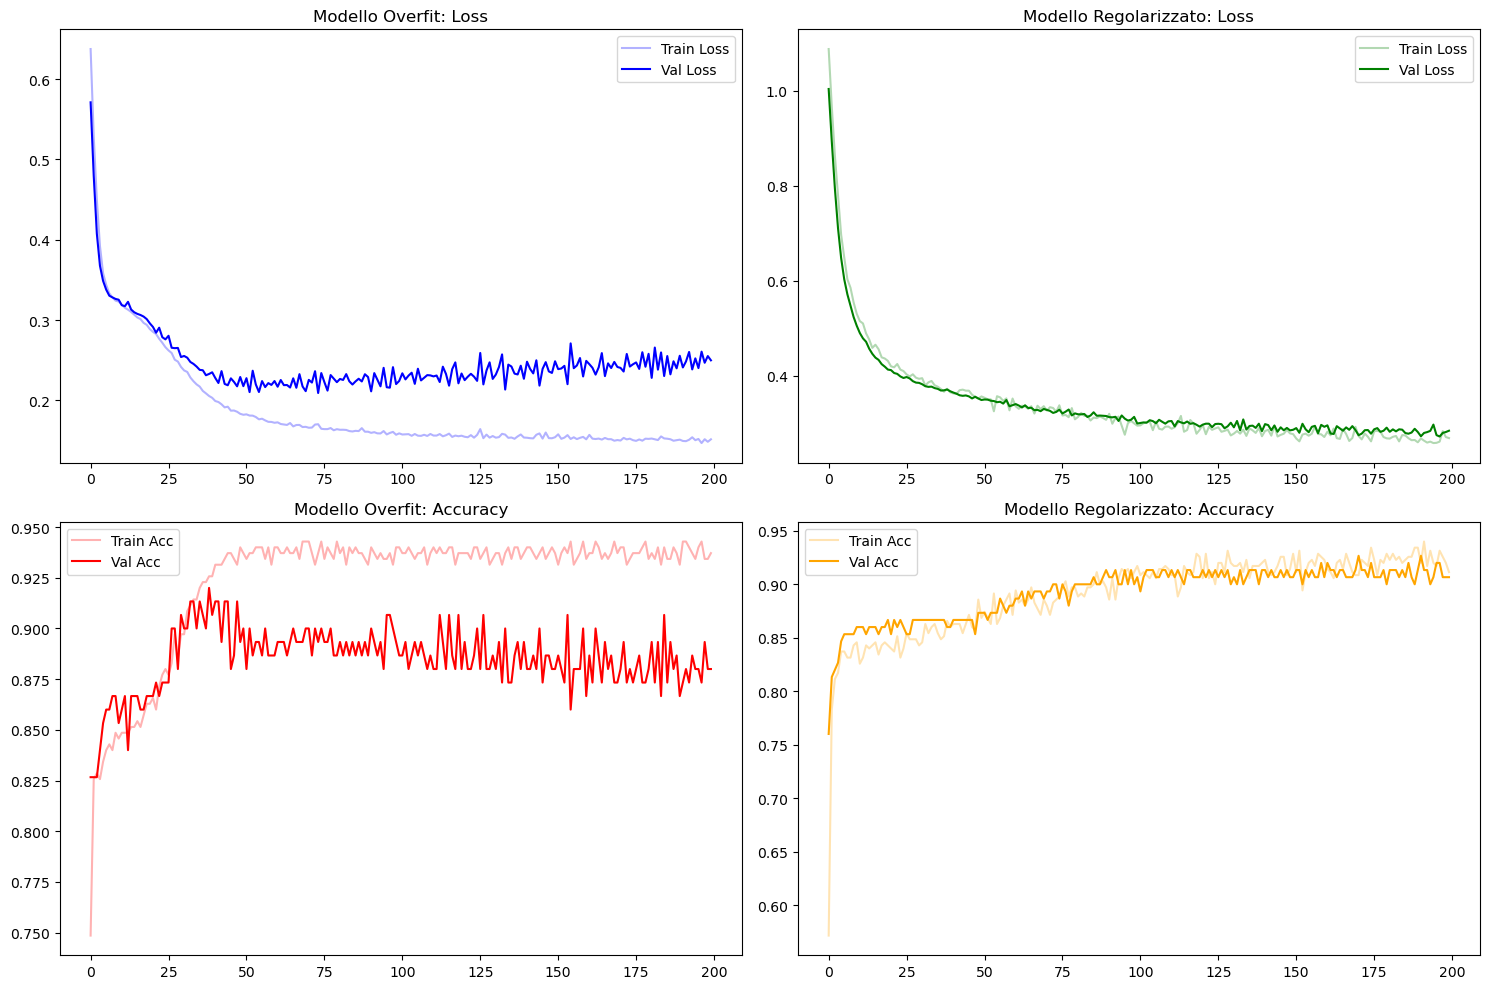

Modello Overfit terminato a epoca 200
Modello Regolarizzato terminato a epoca 200


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# 1. GENERAZIONE DATI RUMOROSI (Dataset complesso per indurre errore)
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- MODELLO 1: OVERFITTING (Senza regolarizzazione) ---
def build_overfit_model():
    model = Sequential([
        Input(shape=(2,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid') #problema di classificazione binaria
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- MODELLO 2: REGOLARIZZATO (L2 + Dropout) ---
def build_regularized_model():
    model = Sequential([
        Input(shape=(2,)),
        # L2 Regularization: "tassa" sui pesi grandi
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        # Dropout: spegnimento casuale dei neuroni
        Dropout(0.4),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. CONFIGURAZIONE EARLY STOPPING
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

# 3. ADDESTRAMENTO
print("Addestramento Modello Overfit...")
model_overfit = build_overfit_model()
history_overfit = model_overfit.fit(
    X_train, y_train, epochs=200, batch_size=32,
    validation_data=(X_test, y_test), verbose=0
)

print("Addestramento Modello Regolarizzato...")
model_reg = build_regularized_model()
history_reg = model_reg.fit(
    X_train, y_train, epochs=200, batch_size=32,
    validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0
)

# 4. VISUALIZZAZIONE COMPARATIVA
plt.figure(figsize=(15, 10))

# --- PLOT LOSS ---
plt.subplot(2, 2, 1)
plt.plot(history_overfit.history['loss'], label='Train Loss', color='blue', alpha=0.3)
plt.plot(history_overfit.history['val_loss'], label='Val Loss', color='blue')
plt.title('Modello Overfit: Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history_reg.history['loss'], label='Train Loss', color='green', alpha=0.3)
plt.plot(history_reg.history['val_loss'], label='Val Loss', color='green')
plt.title('Modello Regolarizzato: Loss')
plt.legend()

# --- PLOT ACCURACY ---
plt.subplot(2, 2, 3)
plt.plot(history_overfit.history['accuracy'], label='Train Acc', color='red', alpha=0.3)
plt.plot(history_overfit.history['val_accuracy'], label='Val Acc', color='red')
plt.title('Modello Overfit: Accuracy')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(history_reg.history['accuracy'], label='Train Acc', color='orange', alpha=0.3)
plt.plot(history_reg.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Modello Regolarizzato: Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Modello Overfit terminato a epoca 200")
print(f"Modello Regolarizzato terminato a epoca {len(history_reg.history['loss'])}")

Applicare o meno la regolarizzazione la curva di training scende verso lo zero mentre la curva di validazione inizia a salire.
Con early stopping le due curve restano vicine, se saparano troppo significa che il  modello sta iniziando ad inventare storie sui dati.

L1 eL2 mentengono i pesi piccoli
Dropout forza l'indipendenza dei neuroni (features)
Early Stopping permette di fermarsi quando la validazione smette di miglioare per avere il miglior modello possibile